<div align="center">

# <span style="color: #3498db;">CA2 - Genetic & Game</span>

**<span style="color:rgb(247, 169, 0);">[Student Name]</span> - <span style="color:rgb(143, 95, 195);">[Student Number]</span>**

</div>


<div style="font-family: Arial, sans-serif; line-height: 1.6;">

### 📊 Matplotlib – Data Visualization in Python  

matplotlib is a python library that is mainly used for data visualization. This library allows you to plot different type of figures including scatters and histograms. In the first part of this project you are supposed to implement a genetic algorithm. To visualize plots that are required in the project description use plotting as much as you can because it gives a great insight on what is happening during each run. It also helps you to compare your results whenevever you want to understand effect of different parameters during different runs.
For more information, check [this notebook](https://github.com/jakevdp/PythonDataScienceHandbook/blob/master/notebooks/04.00-Introduction-To-Matplotlib.ipynb) and visit [the website](https://matplotlib.org/stable/tutorials/pyplot.html#sphx-glr-tutorials-pyplot-py).

In [1]:
import matplotlib.pyplot as plt

# <span style="color: #3498db;">Genetic Algorithm</span>

In [1]:
import random
import itertools
import numpy as np

In [2]:
# algorithm parameters
numCoeffs = 41
populationSize = 100
generations = 50
mutationRate = 0.15
functionRange = (-np.pi, np.pi)
sampleCount = 100

In [3]:
# These functions are given as samples to use in the algorithm
def getTargetFunction(functionName="sin_cos"):
    def sinCosFunction(t):
        """Target function: sin(2πt) + 0.5*cos(4πt)."""
        return np.sin(2 * np.pi * t) + 0.5 * np.cos(4 * np.pi * t)

    def linearFunction(t):
        """Simple linear function: y = 2t + 1."""
        return 2 * t + 1

    def quadraticFunction(t):
        """Quadratic function: y = 4t^2 - 4t + 2."""
        return 4 * (t**2) - 4 * t + 2

    def cubicFunction(t):
        """Cubic function: y = 8t^3 - 12t^2 + 6t."""
        return 8 * (t**3) - 12 * (t**2) + 6 * t

    def gaussianFunction(t):
        """Gaussian function centered at t=0.5."""
        mu = 0.5
        sigma = 0.1  # Adjust sigma to control the width of the peak
        return np.exp(-((t - mu) ** 2) / (2 * sigma**2))

    def squareWaveFunction(t):
        """Approximation of a square wave. Smoothed for better Fourier approximation."""
        return 0.5 * (np.sign(np.sin(2 * np.pi * t)) + 1)

    def sawtoothFunction(t):
        """Sawtooth wave, normalized to [0, 1]."""
        return (t * 5) % 1

    def complexFourierFunction(t):
        return (
            np.sin(2 * np.pi * t)
            + 0.3 * np.cos(4 * np.pi * t)
            + 0.2 * np.sin(6 * np.pi * t)
            + 0.1 * np.cos(8 * np.pi * t)
        )

    def polynomialFunction(t):
        return 10 * (t**5) - 20 * (t**4) + 15 * (t**3) - 4 * (t**2) + t + 0.5

    functionOptions = {
        "sin_cos": sinCosFunction,
        "linear": linearFunction,
        "quadratic": quadraticFunction,
        "cubic": cubicFunction,
        "gaussian": gaussianFunction,
        "square_wave": squareWaveFunction,
        "sawtooth": sawtoothFunction,
        "complex_fourier": complexFourierFunction,
        "polynomial": polynomialFunction,
    }

    selectedFunction = functionOptions.get(functionName.lower())
    if selectedFunction:
        return selectedFunction

In [4]:
# generate samples
tSamples = np.linspace(functionRange[0], functionRange[1], sampleCount)
fSamples = getTargetFunction("linear")(tSamples)

gen 1: the best RMSE = 21.3299
gen 2: the best RMSE = 15.3144
gen 3: the best RMSE = 11.0036
gen 4: the best RMSE = 7.9735
gen 5: the best RMSE = 6.1902
gen 6: the best RMSE = 4.8981
gen 7: the best RMSE = 4.4518
gen 8: the best RMSE = 4.0235
gen 9: the best RMSE = 3.9159
gen 10: the best RMSE = 3.7359
gen 11: the best RMSE = 3.6310
gen 12: the best RMSE = 3.4588
gen 13: the best RMSE = 3.3143
gen 14: the best RMSE = 3.2822
gen 15: the best RMSE = 3.1840
gen 16: the best RMSE = 2.8880
gen 17: the best RMSE = 2.8880
gen 18: the best RMSE = 2.8408
gen 19: the best RMSE = 2.6959
gen 20: the best RMSE = 2.6027
gen 21: the best RMSE = 2.5527
gen 22: the best RMSE = 2.4591
gen 23: the best RMSE = 2.2834
gen 24: the best RMSE = 2.2102
gen 25: the best RMSE = 2.1555
gen 26: the best RMSE = 2.1000
gen 27: the best RMSE = 1.9632
gen 28: the best RMSE = 1.8676
gen 29: the best RMSE = 1.8127
gen 30: the best RMSE = 1.7923
gen 31: the best RMSE = 1.6078
gen 32: the best RMSE = 1.5673
gen 33: the be

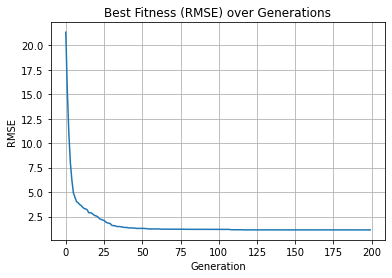

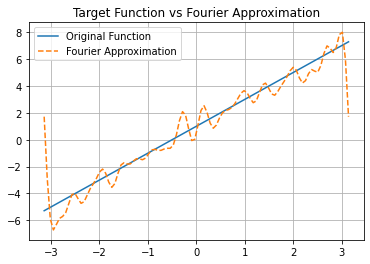

In [ ]:
import matplotlib.pyplot as plt

A = 10

def create_chromosome():
    return np.random.uniform(-A, A, numCoeffs)

def initialize_population():
    return np.array([create_chromosome() for _ in range(populationSize)])

def fourier_series(chromosome, t):
    a0 = chromosome[0]
    an = chromosome[1:21]
    bn = chromosome[21:]
    result = a0 + sum(an[i] * np.cos((i + 1) * t) + bn[i] * np.sin((i + 1) * t) for i in range(20))
    return result

def calculate_fitness(chromosome):
    predicted = fourier_series(chromosome, tSamples)
    rmse = np.sqrt(np.mean((fSamples - predicted) ** 2))
    return rmse

def select_parents(population, fitnesses):
    indices = np.random.choice(len(population), 5, replace=False)
    best_two = sorted(indices, key=lambda i: fitnesses[i])[:2]
    return population[best_two[0]], population[best_two[1]]

def crossover(parent1, parent2):
    alpha = np.random.rand()
    child = alpha * parent1 + (1 - alpha) * parent2
    return child

def mutate(chromosome):
    for i in range(len(chromosome)):
        if np.random.rand() < mutationRate:
            chromosome[i] += np.random.uniform(-1, 1)
            chromosome[i] = np.clip(chromosome[i], -A, A)
    return chromosome

population = initialize_population()
bestFitnessOverTime = []

for gen in range(generations*4):
    fitnesses = np.array([calculate_fitness(ind) for ind in population])
    nextGeneration = []

    bestIndex = np.argmin(fitnesses)
    bestChromosome = population[bestIndex]
    bestFitnessOverTime.append(fitnesses[bestIndex])
    nextGeneration.append(bestChromosome.copy())

    while len(nextGeneration) < populationSize:
        p1, p2 = select_parents(population, fitnesses)
        child = crossover(p1, p2)
        child = mutate(child)
        nextGeneration.append(child)

    population = np.array(nextGeneration)

    print(f"gen {gen+1}: the best RMSE = {bestFitnessOverTime[-1]:.4f}")

plt.plot(bestFitnessOverTime)
plt.title("Best Fitness (RMSE) over Generations")
plt.xlabel("Generation")
plt.ylabel("RMSE")
plt.grid(True)
plt.show()

bestPrediction = fourier_series(bestChromosome, tSamples)
plt.plot(tSamples, fSamples, label="Original Function")
plt.plot(tSamples, bestPrediction, label="Fourier Approximation", linestyle="--")
plt.legend()
plt.title("Target Function vs Fourier Approximation")
plt.grid(True)
plt.show()

# <span style="color: #3498db;">Minmax Algorithm</span>

In [8]:
import random
import numpy as np
from math import inf
import time
#import pygame

In [9]:
import random
import numpy as np
from math import inf
import time

class PentagoGame:
    def __init__(self, ui=True, print=True, depth=2):
        self.board = np.zeros((6, 6), dtype=int)
        self.current_player = 1
        self.ui = ui
        self.depth = depth
        self.nodes_visited = 0
        self.game_over = False
        self.result = None
        self.selected_block = None
        self.move_stage = 0  # 0: place piece, 1: select block, 2: rotate
        self.temp_piece = None
        self.print = print

        if ui:
            pygame.font.init()
            self.screen = pygame.display.set_mode((800, 600))
            pygame.display.set_caption("Pygame Board")
            # self.font = pygame.font.SysFont("Arial", 20)
            self.show_buttons = False
            self.buttons = {
                "rotate_cw": pygame.Rect(650, 200, 100, 50),
                "rotate_ccw": pygame.Rect(650, 300, 100, 50),
            }
            self.setup_controls()
            self.draw_board()

    def setup_controls(self):
        if self.show_buttons:
            pygame.draw.rect(self.screen, (144, 238, 144), self.buttons["rotate_cw"])  # Light Green
            pygame.draw.rect(self.screen, (173, 216, 230), self.buttons["rotate_ccw"])  # Light Blue

            self.screen.draw_text("CLOCKWISE", self.buttons["rotate_cw"].center)
            self.screen.draw_text("COUNTER-CLOCKWISE", self.buttons["rotate_ccw"].center)

    def hide_rotation_buttons(self):
        self.show_buttons = False

    def show_rotation_buttons(self):
        self.show_buttons = True

    def copy_board(self, board):
        return np.copy(board)

    def rotate_block(self, board, block, direction):
        row_start = (block // 2) * 3
        col_start = (block % 2) * 3
        sub = board[row_start: row_start + 3, col_start: col_start + 3]
        rotated = np.rot90(sub, 3 if direction == "cw" else 1)
        board[row_start: row_start + 3, col_start: col_start + 3] = rotated

    def get_possible_moves(self, board, player):
        moves = []
        for i in range(6):
            for j in range(6):
                if board[i][j] == 0:
                    for block in range(4):
                        for dir in ["cw", "ccw"]:
                            moves.append((i, j, block, dir))
        return moves

    def apply_move(self, board, move, player):
        new_board = self.copy_board(board)
        row, col, block, direction = move
        if new_board[row][col] != 0:
            return None
        new_board[row][col] = player
        self.rotate_block(new_board, block, direction)
        return new_board

    def check_winner(self, board):
        for i in range(6):
            for j in range(6):
                if board[i][j] == 0:
                    continue

                # Horizontal
                if j <= 1 and np.all(board[i, j: j + 5] == board[i][j]):
                    return board[i][j]

                # Vertical
                if i <= 1 and np.all(board[i: i + 5, j] == board[i][j]):
                    return board[i][j]

                # Diagonal
                if (
                        i <= 1
                        and j <= 1
                        and all(board[i + k][j + k] == board[i][j] for k in range(5))
                ):
                    return board[i][j]

                # Anti-diagonal
                if (
                        i <= 1
                        and j >= 4
                        and all(board[i + k][j - k] == board[i][j] for k in range(5))
                ):
                    return board[i][j]
        if np.all(board != 0):
            return 0
        return None

    def evaluate_board(self, board, player):
        score = 0

        def check_line(line):
            count = line.count(player)
            if count == 5:
                return 100000
            elif count == 4 and line.count(0) == 1:
                return 1000
            elif count == 3 and line.count(0) == 2:
                return 100
            return 0

        lines = []

        # Rows and columns
        for i in range(6):
            for j in range(2):  # 0~1, 1~2, ..., 1~5
                lines.append(list(board[i, j:j + 5]))
                lines.append(list(board[j:j + 5, i])) 

        # Diagonals
        for i in range(2):
            for j in range(2):
                lines.append([board[i + k][j + k] for k in range(5)])  # Main diag
                lines.append([board[i + k][j + 4 - k] for k in range(5)])  # Anti-diag

        for line in lines:
            score += check_line(line)

        opponent = -player
        for line in lines:
            score -= check_line([opponent if x == opponent else 0 for x in line])

        return score

    def minimax(self, board, depth, maximizing_player):
        winner = self.check_winner(board)
        if depth == 0 or winner is not None:
            if(maximizing_player):
                player = 1
            else:
                player = -1
            return self.evaluate_board(board, player)

        self.nodes_visited += 1

        if maximizing_player:
            max_eval = -float('inf')
            for move in self.get_possible_moves(board, 1):
                new_board = self.apply_move(board, move, 1)
                if new_board is None:
                    continue
                eval = self.minimax(new_board, depth - 1, False)
                max_eval = max(max_eval, eval)
            return max_eval
        else:
            min_eval = float('inf')
            for move in self.get_possible_moves(board, -1):
                new_board = self.apply_move(board, move, -1)
                if new_board is None:
                    continue
                eval = self.minimax(new_board, depth - 1, True)
                min_eval = min(min_eval, eval)
            return min_eval

    def alpha_beta(self, board, depth, alpha, beta, maximizing):
        winner = self.check_winner(board)
        if winner is not None:
            return winner * 100000
        if depth == 0:
            return self.evaluate_board(board, 1 if maximizing else -1)

        self.nodes_visited += 1
        player = 1 if maximizing else -1

        if maximizing:
            value = -inf
            for move in self.get_possible_moves(board, player):
                new_board = self.apply_move(board, move, player)
                if new_board is None:
                    continue
                value = max(value, self.alpha_beta(new_board, depth - 1, alpha, beta, False))
                alpha = max(alpha, value)
                if alpha >= beta:
                    break  # beta cut-off
            return value
        else:
            value = inf
            for move in self.get_possible_moves(board, player):
                new_board = self.apply_move(board, move, player)
                if new_board is None:
                    continue
                value = min(value, self.alpha_beta(new_board, depth - 1, alpha, beta, True))
                beta = min(beta, value)
                if beta <= alpha:
                    break  # alpha cut-off
            return value

    def get_computer_move(self):
        start_time = time.time()
        best_move = None
        best_value = -inf

        moves = self.get_possible_moves(self.board, -1)
        if not moves:
            return None
        best_move = moves[0]

        for move in moves:
            if self.game_over:
                break
            new_board = self.apply_move(self.board, move, -1)
            if new_board is None:
                continue

            try:
                value = self.minimax(new_board, self.depth - 1, False)
                # TODO: Implement alpha-beta pruning algorithm
                value = self.alpha_beta(new_board, self.depth - 1, -inf, inf, True)

            except:
                value = -inf
            #print(value)
            if value > best_value:
                best_value = value
                best_move = move

        if self.print == True:
            print(f"Move took {time.time() - start_time:.2f}s, nodes visited: {self.nodes_visited}")
        self.nodes_visited = 0
        return best_move

    def draw_text(self, text, center_pos, max_width):
        font_size = 24
        font = pygame.font.Font(None, font_size)
        text_surface = font.render(text, True, (0, 0, 0))

        text_width = text_surface.get_width()
        if text_width > max_width:
            scale_factor = max_width / text_width
            new_font_size = int(font_size * scale_factor)
            font = pygame.font.Font(None, new_font_size)
            text_surface = font.render(text, True, (0, 0, 0))

        text_rect = text_surface.get_rect(center=center_pos)
        self.screen.blit(text_surface, text_rect)

    def draw_board(self):
        self.screen.fill((0, 0, 0))

        for i in range(6):
            for j in range(6):
                x0 = j * 100
                y0 = i * 100

                if self.board[i][j] == 1:
                    pygame.draw.circle(self.screen, (255, 0, 0), (x0 + 50, y0 + 50), 40)
                elif self.board[i][j] == -1:
                    pygame.draw.circle(self.screen, (0, 0, 255), (x0 + 50, y0 + 50), 40)

                pygame.draw.rect(self.screen, (255, 255, 255), (x0, y0, 100, 100), 1)

        for i in [3, 6]:
            pygame.draw.line(self.screen, (255, 255, 255), (0, i * 100), (600, i * 100), 3)  # Horizontal
            pygame.draw.line(self.screen, (255, 255, 255), (i * 100, 0), (i * 100, 600), 3)  # Vertical

        # Show rotation buttons if in move_stage 2
        if self.move_stage == 2:
            self.highlight_selected_block()
            self.show_rotation_buttons()

        if self.show_buttons:
            pygame.draw.rect(self.screen, (144, 238, 144), self.buttons["rotate_cw"])  # Light Green
            pygame.draw.rect(self.screen, (173, 216, 230), self.buttons["rotate_ccw"])  # Light Blue

            self.draw_text(
                "CLOCKWISE",
                self.buttons["rotate_cw"].center,
                self.buttons["rotate_cw"].width,
            )
            self.draw_text(
                "COUNTER-CLOCKWISE",
                self.buttons["rotate_ccw"].center,
                self.buttons["rotate_ccw"].width,
            )

    def click_handler(self, event):
        if self.game_over or self.current_player != 1:
            return

        x, y = event.pos
        if self.move_stage == 0:  # Place piece
            if x > 600:
                return  # clicks on control area
            col = x // 100
            row = y // 100
            if 0 <= row < 6 and 0 <= col < 6 and self.board[row][col] == 0:
                self.temp_piece = (row, col)
                self.board[row][col] = 1
                self.move_stage = 1
                self.draw_board()

        elif self.move_stage == 1:  # Select block
            if x > 600:
                return
            # which block was clicked
            block_x = 0 if x < 300 else 1
            block_y = 0 if y < 300 else 1
            self.selected_block = block_y * 2 + block_x
            self.move_stage = 2
            self.show_rotation_buttons()
            self.highlight_selected_block()

        elif self.move_stage == 2:  # Rotate
            if self.buttons["rotate_cw"].collidepoint(event.pos):
                self.apply_rotation("cw")
            if self.buttons["rotate_ccw"].collidepoint(event.pos):
                self.apply_rotation("ccw")

    def apply_rotation(self, direction):
        self.rotate_block(self.board, self.selected_block, direction)
        self.current_player = -1
        self.move_stage = 0
        self.selected_block = None
        self.temp_piece = None
        self.hide_rotation_buttons()
        self.draw_board()
        pygame.display.flip()
        self.check_game_over()
        pygame.time.delay(1000)
        self.play_computer_move()

    def highlight_selected_block(self):
        colors = [
            (255, 153, 153),
            (153, 255, 153),
            (153, 153, 255),
            (255, 255, 153),
        ]  # RGB colors

        row_start = (self.selected_block // 2) * 3
        col_start = (self.selected_block % 2) * 3

        pygame.draw.rect(
            self.screen,
            colors[self.selected_block],
            (col_start * 100, row_start * 100, 300, 300),
            5,
        )

    def play_computer_move(self):
        move = self.get_computer_move()
        if move and not self.game_over:
            new_board = self.apply_move(self.board, move, -1)
            if new_board is not None:
                self.board = new_board
                self.current_player = 1
                self.draw_board()
                pygame.display.flip()
                self.check_game_over()
            else:
                print("Invalid computer move!")

    def check_game_over(self):
        winner = self.check_winner(self.board)
        if winner is not None:
            self.game_over = True
            self.result = winner
            print("Game over! Result:", winner)
            if self.ui:
                self.show_game_over_message()

    def show_game_over_message(self):
        self.screen.fill((200, 200, 200))
        pygame.draw.rect(self.screen, (255, 255, 255), (100, 200, 500, 200))
        pygame.draw.rect(self.screen, (0, 0, 0), (100, 200, 500, 200), 3)

        result_text = f"Player {self.result} wins!" if self.result != 0 else "Draw!"
        text_surface = self.font_large.render(result_text, True, (255, 0, 0))
        self.screen.blit(text_surface, (250, 250))

        exit_text = self.font_small.render("Click anywhere to exit", True, (0, 0, 0))
        self.screen.blit(exit_text, (230, 350))
        pygame.display.flip()

    def play(self):
        if self.ui:
            running = True
            while running:
                for event in pygame.event.get():
                    if event.type == pygame.QUIT:
                        running = False
                    elif event.type == pygame.MOUSEBUTTONDOWN:
                        self.click_handler(event)
                self.draw_board()
                pygame.display.flip()
            pygame.quit()
            return self.result
        else:
            while not self.game_over:
                self.print_board()
                winner = self.check_winner(self.board)
                if winner is not None:
                    return winner

                if self.current_player == 1:
                    move = random.choice(self.get_possible_moves(self.board, 1))
                else:
                    move = self.get_computer_move()

                self.board = self.apply_move(self.board, move, self.current_player)
                self.current_player *= -1
            return self.result

    def print_board(self):
        if self.print == False:
            return
        print("-" * 25)
        for row in self.board:
            print(" ".join(f"{x:2}" for x in row))
        print("-" * 25)


In [10]:
if __name__ == "__main__":
    numGames = 10
    numWins, numTies, numLosses = 0, 0, 0
    for i in range(numGames):
        game = PentagoGame(ui=False, print=True, depth=1)  # depth=2 for faster
        result = game.play()
        if result == -1:
            numWins += 1
        elif result == 0:
            numTies += 1
        else:
            numLosses += 1

    print(f"{numWins} wins, {numTies} ties, {numLosses} losses")


-------------------------
 0  0  0  0  0  0
 0  0  0  0  0  0
 0  0  0  0  0  0
 0  0  0  0  0  0
 0  0  0  0  0  0
 0  0  0  0  0  0
-------------------------
-------------------------
 0  0  0  0  1  0
 0  0  0  0  0  0
 0  0  0  0  0  0
 0  0  0  0  0  0
 0  0  0  0  0  0
 0  0  0  0  0  0
-------------------------
Move took 0.09s, nodes visited: 0
-------------------------
 0  0 -1  0  1  0
 0  0  0  0  0  0
 0  0  0  0  0  0
 0  0  0  0  0  0
 0  0  0  0  0  0
 0  0  0  0  0  0
-------------------------
-------------------------
 0  0 -1  0  1  0
 0  0  0  0  1  0
 0  0  0  0  0  0
 0  0  0  0  0  0
 0  0  0  0  0  0
 0  0  0  0  0  0
-------------------------
Move took 0.08s, nodes visited: 0
-------------------------
 0  0 -1  0  1  0
 0  0  0  0  1  0
 0  0 -1  0  0  0
 0  0  0  0  0  0
 0  0  0  0  0  0
 0  0  0  0  0  0
-------------------------
-------------------------
 1  0 -1  0  1  0
 0  0  0  0  1  0
 0  0 -1  0  0  0
 0  0  0  0  0  0
 0  0  0  0  0  0
 0  0  0  0  0  

Move took 0.08s, nodes visited: 0
-------------------------
 0  0 -1  0  0  0
 0  0  0  0  0  0
 0  0 -1  0  0  0
 0  0  0  0  1  0
 0  0  0  0  0  1
 0  0  0  0  0  0
-------------------------
-------------------------
 0  0  0  0  0  0
 0  0  0  0  0  0
-1  0 -1  0  0  0
 0  0  0  0  1  0
 0  0  0  1  0  1
 0  0  0  0  0  0
-------------------------
Move took 0.08s, nodes visited: 0
-------------------------
-1  0 -1  0  0  0
 0  0  0  0  0  0
-1  0  0  0  0  0
 0  0  0  0  1  0
 0  0  0  1  0  1
 0  0  0  0  0  0
-------------------------
-------------------------
-1  0 -1  0  0  0
 0  0  0  0  0  0
 0  0 -1  0  0  0
 0  0  0  0  1  0
 0  0  1  1  0  1
 0  0  0  0  0  0
-------------------------
Move took 0.08s, nodes visited: 0
-------------------------
 0  0 -1  0  0  0
 0  0 -1  0  0  0
-1  0 -1  0  0  0
 0  0  0  0  1  0
 0  0  1  1  0  1
 0  0  0  0  0  0
-------------------------
-------------------------
 0  0 -1  0  0  0
 0  0 -1  1  0  0
-1  0 -1  0  0  0
 0  0  0  0  1  0


Move took 0.08s, nodes visited: 0
-------------------------
 0  0 -1  0  0  1
 0  0  0  0  0  0
 0  0 -1  0  0  0
 0  0  0  0  0  0
 0  0  0  0  0  0
 0  0  0  1  0  0
-------------------------
-------------------------
 0  0 -1  0  0  1
 0  0  0  0  0  0
 0  0 -1  0  0  0
 0  0  0  0  0  0
 0  0  0  0  1  0
 0  0  0  1  0  0
-------------------------
Move took 0.07s, nodes visited: 0
-------------------------
 0  0 -1  0  0  1
 0  0  0  0  0  0
-1  0 -1  0  0  0
 0  0  0  0  0  0
 0  0  0  0  1  0
 0  0  0  1  0  0
-------------------------
-------------------------
 0  0 -1  0  0  1
 0  0  0  0  0  1
-1  0 -1  0  0  0
 0  0  0  1  0  0
 0  0  0  0  1  0
 0  0  0  0  0  0
-------------------------
Move took 0.07s, nodes visited: 0
-------------------------
-1  0 -1  0  0  1
 0  0  0  0  0  1
-1  0 -1  0  0  0
 0  0  0  0  0  1
 0  0  0  0  1  0
 0  0  0  0  0  0
-------------------------
-------------------------
-1  0 -1  0  0  1
 0  0  0  0  0  1
-1  0 -1  0  0  0
 1  0  0  0  0  1


Move took 0.11s, nodes visited: 0
-------------------------
-1  0 -1 -1  0  0
-1  1  0  1  0  1
-1 -1 -1  0  1 -1
 0  0  0  0  0  1
 0  0  0  0  1  0
 0  0  1  0  1  0
-------------------------
-------------------------
-1  0 -1 -1  0  0
-1  1  0  1  0  1
-1 -1 -1  0  1 -1
 0  0  0  0  0  0
 0  0  0  1  1  1
 0  0  1  0  0  1
-------------------------
Move took 0.07s, nodes visited: 0
-------------------------
-1 -1 -1 -1  0  0
-1  1  0  1  0  1
-1 -1 -1  0  1 -1
 0  0  0  0  1  0
 0  0  0  0  1  0
 0  0  1  1  1  0
-------------------------
-------------------------
-1 -1 -1 -1  0  0
-1  1  0  1  0  1
-1 -1 -1  0  1 -1
 0  0  0  0  0  0
 0  1  0  1  1  1
 0  0  1  0  0  1
-------------------------
Move took 0.05s, nodes visited: 0
-------------------------
-1 -1 -1 -1  0 -1
-1  1  0  1  0  1
-1 -1 -1  0  1 -1
 0  0  0  0  1  0
 0  1  0  0  1  0
 0  0  1  1  1  0
-------------------------
-------------------------
-1 -1 -1 -1  0 -1
-1  1  0  1  0  1
-1 -1 -1  0  1 -1
 0  0  1  0  1  0


Move took 0.07s, nodes visited: 0
-------------------------
-1 -1 -1  0  0  1
-1  0 -1  1  1  0
-1 -1  1 -1  0  1
 0  1  0  0  0  1
 0  0  0  0  0  0
 0  0  0  0  0  1
-------------------------
-------------------------
-1 -1 -1  0  0  1
-1  0 -1  1  1  0
-1 -1  1 -1  0  1
 0  0  0  0  0  1
 0  0  1  0  0  1
 0  0  0  0  0  1
-------------------------
Move took 0.06s, nodes visited: 0
-------------------------
-1 -1 -1 -1  0  1
-1  0 -1  1  1  0
-1 -1  1 -1  0  1
 0  1  0  0  0  1
 0  0  0  0  0  1
 0  0  0  0  0  1
-------------------------
-------------------------
-1 -1 -1 -1  0  1
-1  0 -1  1  1  0
 1 -1 -1 -1  0  1
 0  1  0  0  0  1
 1  0  0  0  0  1
 0  0  0  0  0  1
-------------------------
Move took 0.06s, nodes visited: 0
-------------------------
-1 -1 -1 -1  0  1
-1 -1 -1  1  1  0
-1 -1  1 -1  0  1
 0  1  0  0  0  1
 1  0  0  0  0  1
 0  0  0  0  0  1
-------------------------
-------------------------
-1 -1 -1 -1  0  1
-1 -1 -1  1  1  0
-1 -1  1 -1  0  1
 0  1  0  1  1  1
